# Short Duration Comparison

Flexible short-duration notebook. Build views by genotype, line, cohort, dataset, animal, or custom combinations, prepare the short-duration tables once, then rerun plotting cells without recomputing.

## 1. Setup

In [1]:
from pathlib import Path
import os
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "analysis" / "daily_merge.py").exists() and (candidate / "DataFiles").exists():
        ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find the Mafalda_analysis repo root from the current working directory."
    )

os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

%load_ext autoreload
%autoreload 2

ROOT

PosixPath('/Users/mafaldavalente/Documents/Mafalda_analysis')

## 2. Choose Datasets

`DATASET_SELECTIONS` is the safest option when mixing lines/cohorts. Set it to `None` to use all combinations of `LINES` and `COHORTS`. Use `ANIMAL_SELECTION` for a one-animal short-duration review.

In [7]:
LINES = ["CNTNAP2"]
COHORTS = ["cohort4"]

# Explicit selections can mix lines/cohorts, e.g.:
# DATASET_SELECTIONS = [("CNTNAP2", "cohort2"), ("CNTNAP2", "cohort3"), ("SHANK3", "cohort1")]
DATASET_SELECTIONS = None

# Example: "ASD0026" for a single animal, or None for group comparisons.
ANIMAL_SELECTION = None

## 3. Choose Comparison

Common presets:

- Compare genotypes within selected datasets: `COMPARISON = "genotypes"`, `SPLIT_BY = "none"`
- Keep cohorts/datasets separate within genotype: `COMPARISON = "genotypes"`, `SPLIT_BY = "dataset"`
- Compare the same genotype across datasets: `COMPARISON = "datasets"`, `GENOTYPES = ["hom"]`
- Compare experimentors within selected datasets: `COMPARISON = "experimentor"`
- One view per animal: `COMPARISON = "animals"`
- Fully custom: `COMPARISON = "custom"` and edit `CUSTOM_SPECS`.

In [8]:
COMPARISON = "genotypes"  # "genotypes", "datasets", "lines", "cohorts", "experimentor", "animals", or "custom"
SPLIT_BY = "none"         # for COMPARISON="genotypes": "none", "dataset", "line", or "cohort"
GENOTYPES = ["wt", "het", "hom"]

CUSTOM_SPECS = [
    # {"name": "CNTNAP2 hom all cohorts", "line": "CNTNAP2", "genotype": "hom"},
    # {"name": "SHANK3 hom", "line": "SHANK3", "genotype": "hom"},
]

## 4. Load Data And Build Views

Rerun this if you change dataset selection, comparison mode, genotype selection, or custom specs.

In [9]:
from Pipeline.stimdur import (
    build_stimdur_views,
    build_view_colors,
    build_view_labels,
    load_stimdur_data,
    summarize_views,
)

data = load_stimdur_data(
    lines=LINES,
    cohorts=COHORTS,
    dataset_selections=DATASET_SELECTIONS,
    animal_selection=ANIMAL_SELECTION,
)
df_plot = data["df_plot"]

views = build_stimdur_views(
    df_plot,
    comparison=COMPARISON,
    split_by=SPLIT_BY,
    genotypes=GENOTYPES,
    custom_specs=CUSTOM_SPECS,
)
view_pretty = build_view_labels(views)
view_colors = build_view_colors(views)

print("Loaded datasets:", data["selections"])
print("Usable dataset keys:", data["usable_dataset_names"])
display(summarize_views(df_plot, views))
print("View labels:", view_pretty)
print("View colors:", view_colors)

Loaded datasets: [('CNTNAP2', 'cohort4')]
Usable dataset keys: ['CNTNAP2:cohort4']


,view,animals,trials,datasets
0,wt,4,53133,CNTNAP2:cohort4
1,het,9,103644,CNTNAP2:cohort4
2,hom,6,88327,CNTNAP2:cohort4


View labels: {'wt': 'WT', 'het': 'HET', 'hom': 'HOM'}
View colors: {'wt': '#4D4D4D', 'het': '#7A8F28', 'hom': '#C24A7A'}


## 5. Prepare Once

This is the expensive step. Rerun it if you change filters, selected stim durations, views, or datasets. You do not need to rerun it just to change `PLOT_MODE` below.

In [10]:
from Pipeline.stimdur import DEFAULT_STIM_DURS, prepare_stimdur_comparison
from StimDur.config import FilterConfig, PlotStyle, StimDurComparisonConfig

STIM_DURS = DEFAULT_STIM_DURS

cfg = StimDurComparisonConfig(
    error_mode="individuals",
    skip_psy_fits=(50,),
    ild_shift_for_abl50=True,
)
fcfg = FilterConfig(
    training_min=16,
    session_min=13,
    drop_repeat_trials=True,
    session_type_values=[2],
)
style = PlotStyle(title_fs=24, label_fs=25, tick_fs=24, legend_fs=16)

bundle = prepare_stimdur_comparison(
    df=df_plot,
    views=views,
    stim_durs=STIM_DURS,
    cfg=cfg,
    fcfg=fcfg,
    style=style,
    view_colors=view_colors,
    view_pretty=view_pretty,
)

print("Filtered rows:", len(bundle["df"]))
print("Active stim durations:", [s.name for s in bundle["stimdur_specs"]])

   ABL       JND
0   20  4.734009
1   40  0.020353
2   60  0.328704
   ABL       JND
0   20  0.087561
1   40  0.032805
2   60  0.163016
   ABL       JND
0   20  3.140502
1   40  5.248861
2   60  0.346370
   ABL       JND
0   20  5.029869
1   40  5.113060
2   60  0.031391
   ABL       JND
0   20  5.041436
1   40  1.318866
2   60  3.431726
   ABL       JND
0   20  0.079522
1   40  3.127503
2   60  4.576320
   ABL       JND
0   20  3.004042
1   40  1.929097
2   60  1.350343
   ABL       JND
0   20  1.269645
1   40  1.379944
2   60  1.332798
   ABL       JND
0   20  2.844821
1   40  2.543422
2   60  2.117811
   ABL       JND
0   20  2.289441
1   40  2.045043
2   60  2.824083
   ABL       JND
0   20  2.556903
1   40  1.024075
   ABL       JND
0   20  0.158011
1   40  0.064359
   ABL       JND
0   20  2.569750
1   40  0.072249
2   60  0.060833
   ABL       JND
0   20  0.117616
1   40  0.611557
2   60  3.801553
   ABL       JND
0   20  0.743160
1   40  4.764762
2   60  5.263362
   ABL       J

## 6. Plot From Prepared Data

Change `PLOT_MODE` and rerun this cell without recomputing preparation.

- `by_view`: one 4x3 figure per view, lines are stim durations
- `by_stimdur`: one 4x3 figure per stim duration, lines are views
- `performance_by_view`: one 1x3 performance-over-duration figure per view that Alfonso likes
- `performance_all`: one 3x5 performance-over-duration summary for all views
- `kreg_by_view`: one kernel-regression style figure per view
- `all`: make all figure families

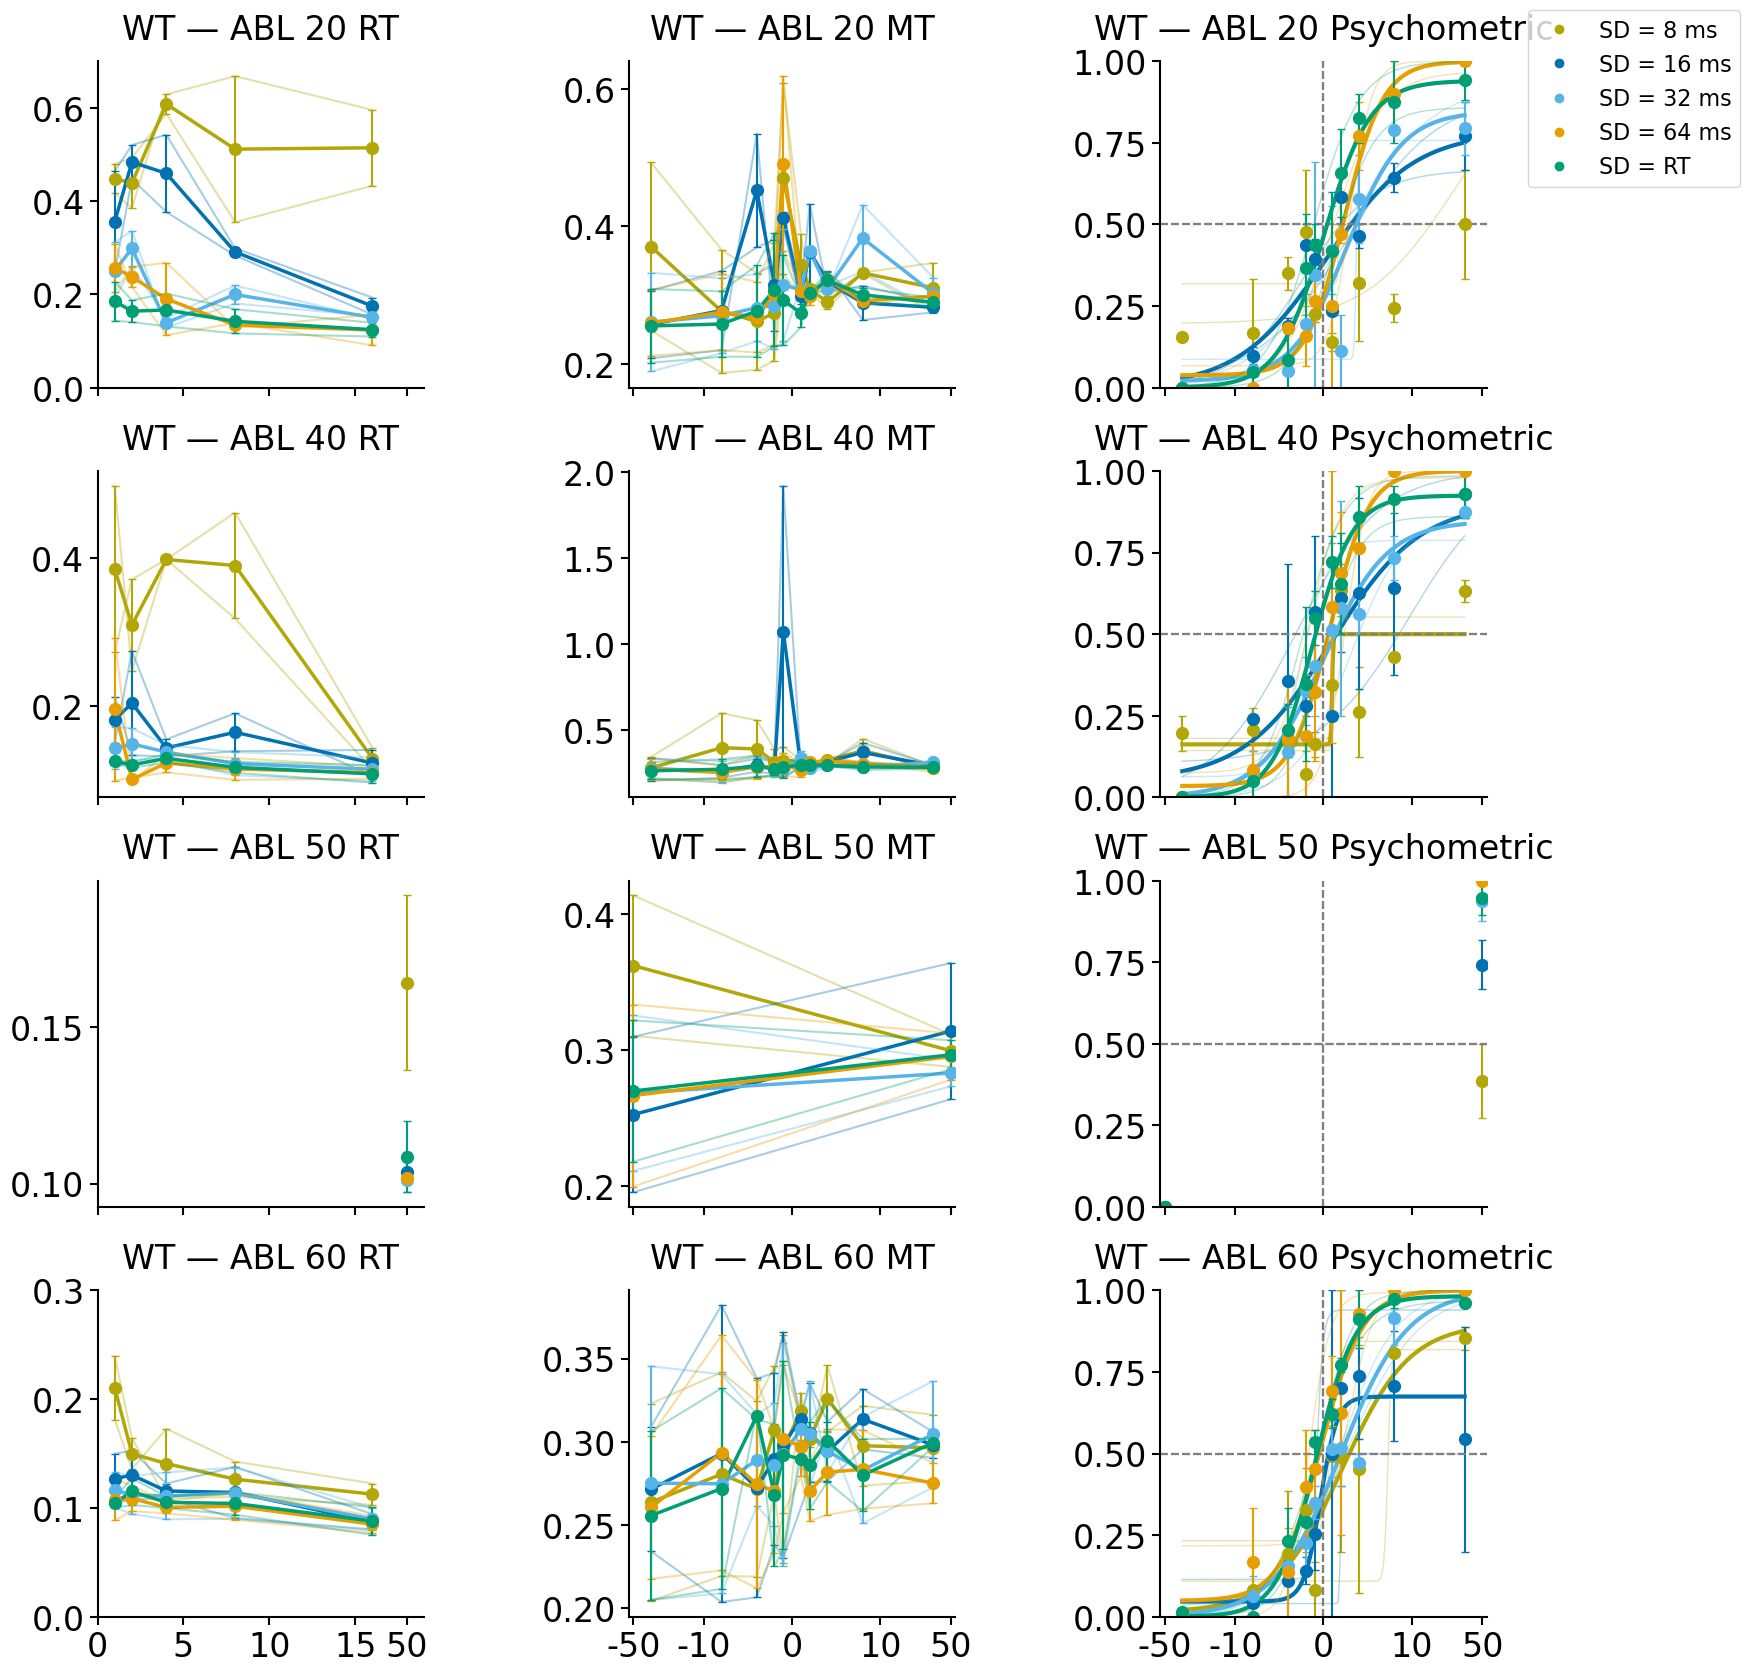

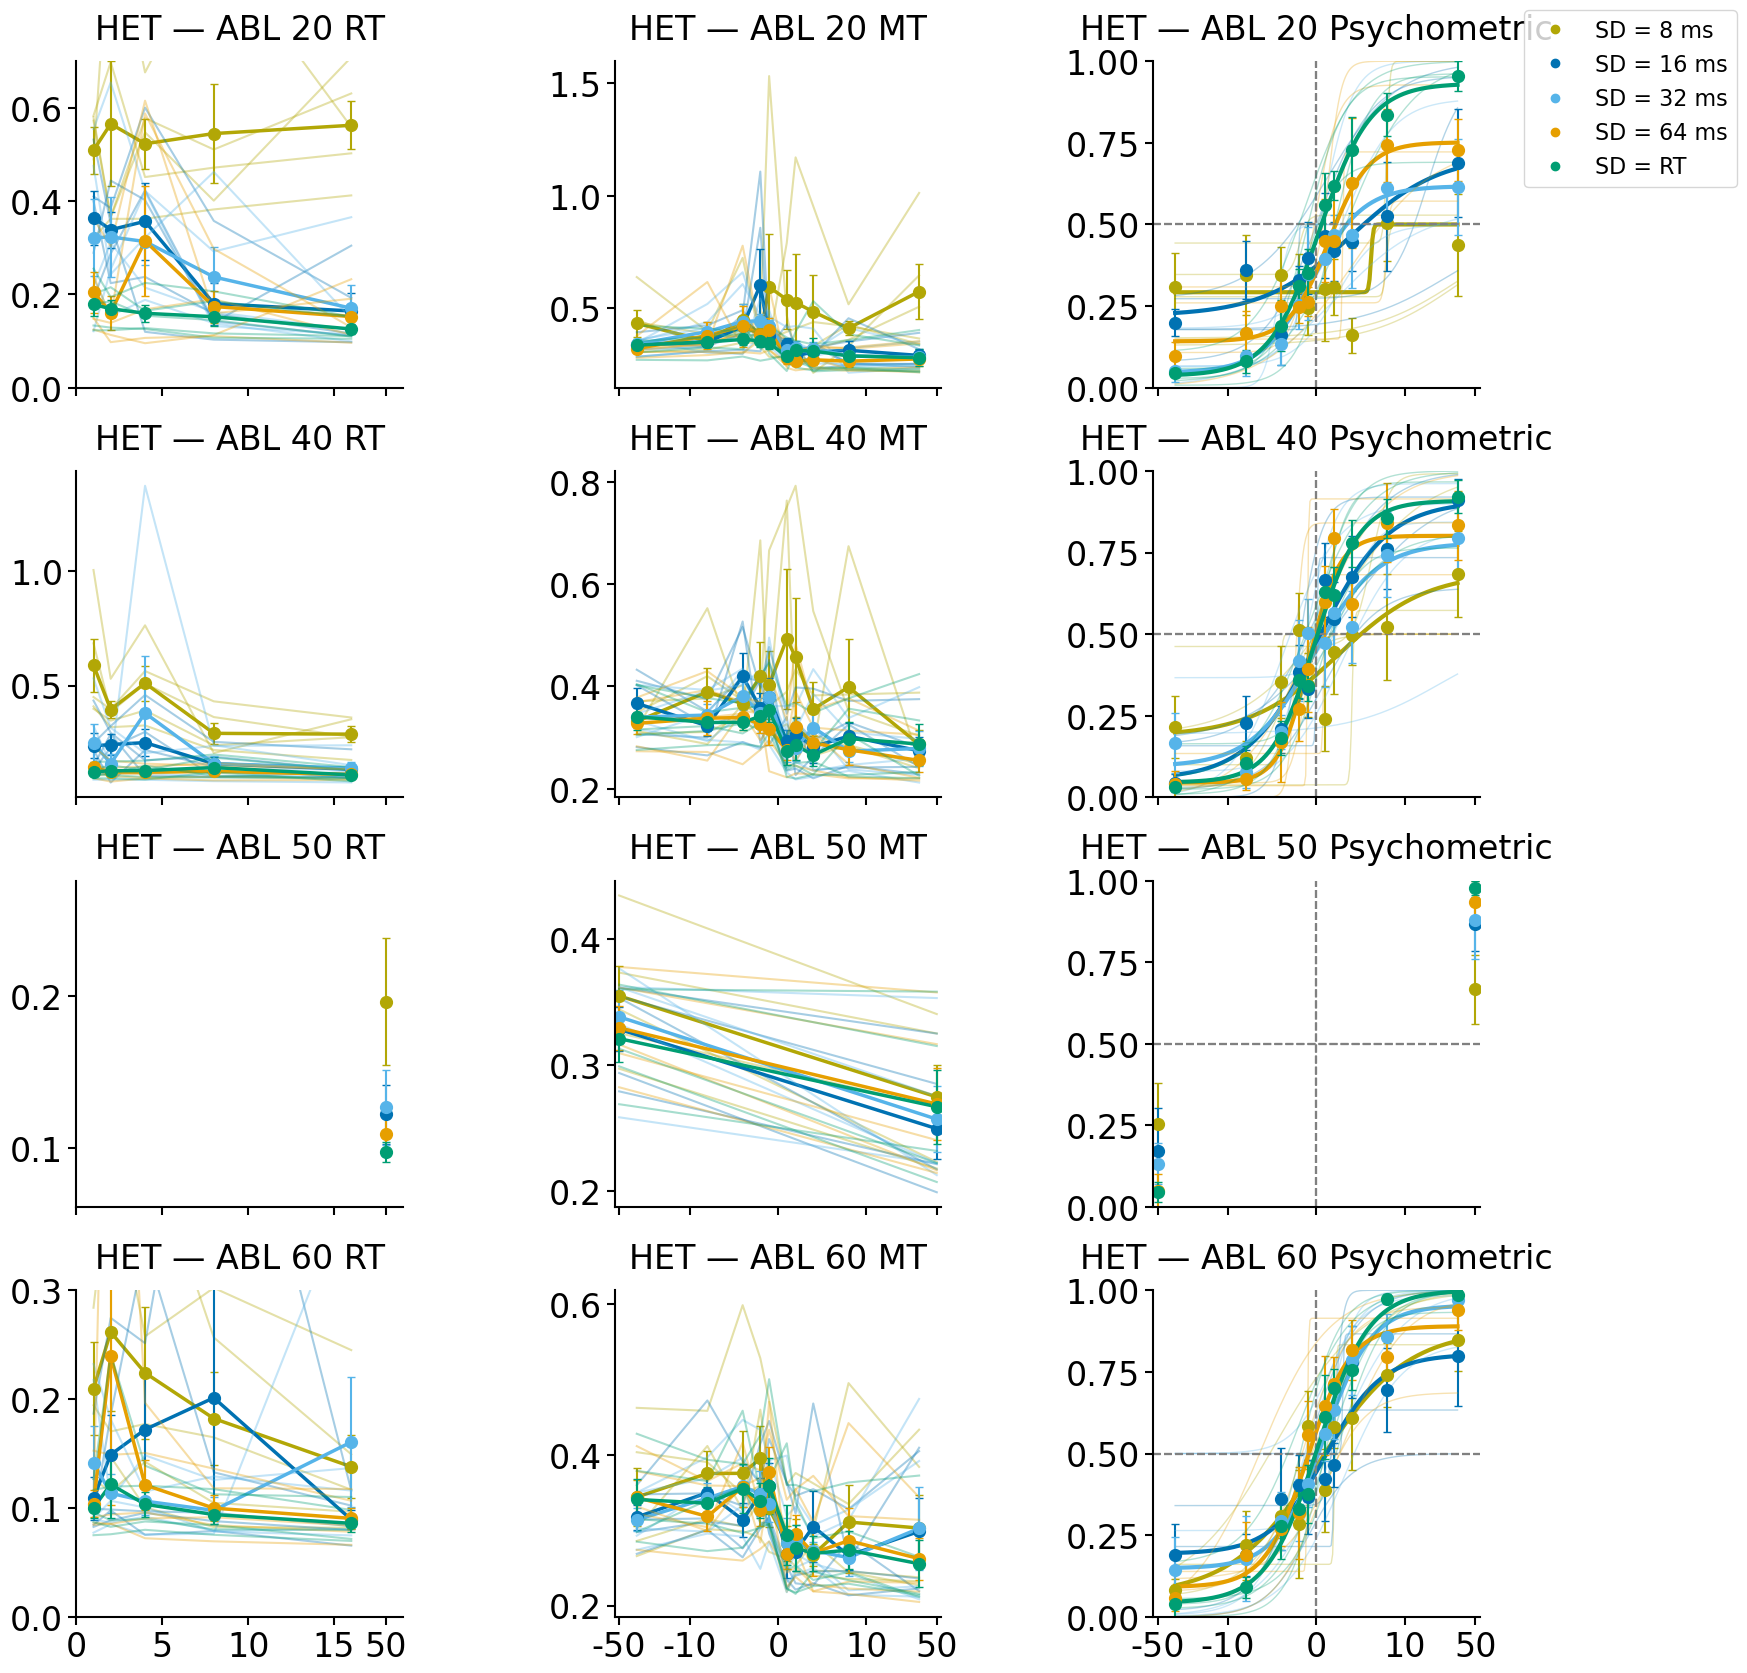

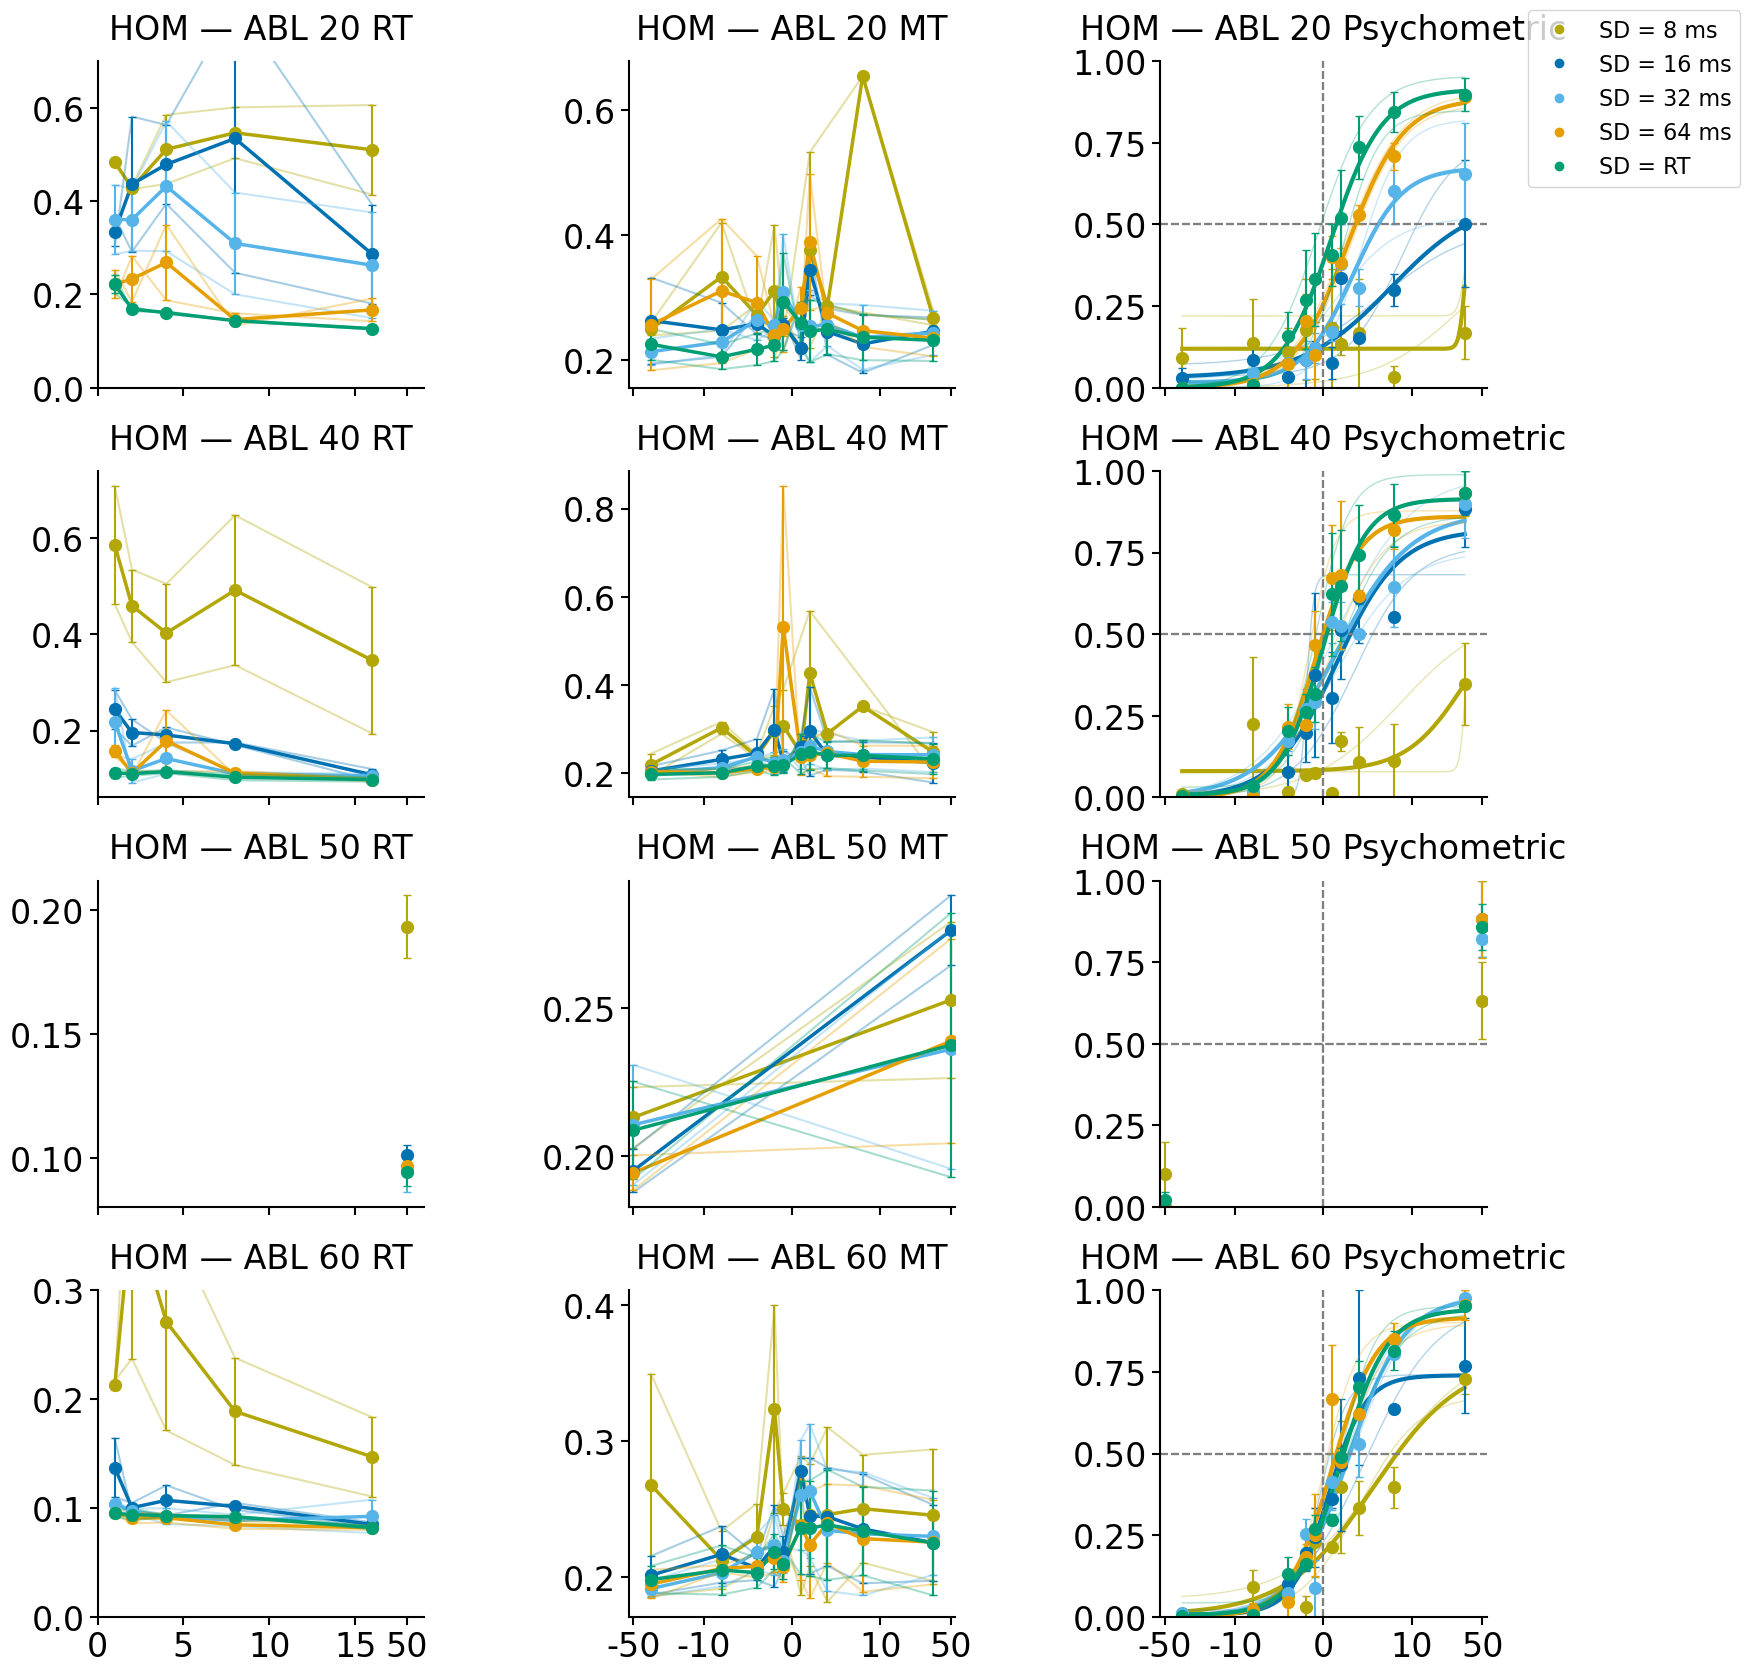

{'by_view': {'wt': <Figure size 1800x1680 with 12 Axes>,
  'het': <Figure size 1800x1680 with 12 Axes>,
  'hom': <Figure size 1800x1680 with 12 Axes>}}

In [11]:
from Pipeline.stimdur import plot_stimdur_comparison

PLOT_MODE = "by_view"

out = plot_stimdur_comparison(
    bundle=bundle,
    views=views,
    plot_mode=PLOT_MODE,
    show=True,
    abls=(20, 40, 60),
    absilds=(1, 2, 4, 8, 16),
)

out["figures"]

## 7. Example Recipes

### Compare genotypes within one cohort

```python
DATASET_SELECTIONS = [("CNTNAP2", "cohort3")]
COMPARISON = "genotypes"
SPLIT_BY = "none"
GENOTYPES = ["wt", "het", "hom"]
```

### Compare genotypes and keep cohorts separate

```python
DATASET_SELECTIONS = [("CNTNAP2", "cohort2"), ("CNTNAP2", "cohort3")]
COMPARISON = "genotypes"
SPLIT_BY = "dataset"
```

### Compare one genotype across datasets

```python
DATASET_SELECTIONS = [("CNTNAP2", "cohort3"), ("SHANK3", "cohort1")]
COMPARISON = "datasets"
GENOTYPES = ["hom"]
```

### Single animal short-duration review

```python
DATASET_SELECTIONS = [("CNTNAP2", "cohort3")]
ANIMAL_SELECTION = "ASD0026"
COMPARISON = "animals"
```

## 8. Optional Save For Google Slides

In [ ]:
SAVE_FIGURES = False

def _save_figures(figures, out_dir, prefix):
    for name, fig in figures.items():
        if isinstance(fig, dict):
            subdir = out_dir / name
            subdir.mkdir(parents=True, exist_ok=True)
            _save_figures(fig, subdir, prefix)
        else:
            fig.savefig(out_dir / f"{prefix}_{name}.png", dpi=250, bbox_inches="tight")

if SAVE_FIGURES:
    out_dir = ROOT / "outputs" / "stim_duration"
    out_dir.mkdir(parents=True, exist_ok=True)
    _save_figures(out["figures"], out_dir, f"stim_duration_{PLOT_MODE}")
    print(out_dir)